# 10 · Stint strategy — the tyre thermal + wear/degradation flagship

M5 gives outlap the piece that turns a *lap* simulator into a *stint* simulator: a physically-based
tyre **thermal ring** (grip that depends on temperature) plus a **wear/degradation** model (grip that
falls as the tread wears, with a cliff). This is the headline of the project — *no open-source tyre
thermal + wear model existed anywhere* — and it is what unlocks race strategy.

This notebook runs the **real** solvers (nothing here re-implements physics) on the reference
**F1 2026** car at **Catalunya** (with the QSS↔T2 agreement cross-checked on the validated Limebeer
reference F1) and shows the three things a stint adds over a lap:

1. **Warm-up + degradation** — cold tyres switch on, then wear + a cliff take the pace away.
2. **QSS ↔ T2 agreement** — the fast quasi-static tier and the full transient tier lose pace at the
   same rate (the parity that makes the QSS tier trustworthy for strategy sweeps).
3. **Multi-compound crossover** — soft/med/hard trade grip for durability, producing a lap-time
   crossover: the stage-2 strategy tease (dry only; wet is stage-2).

The tyre wear/grip parameters were **inverse-calibrated** from a representative stint pace curve by
[`outlap.wearcal`](../python/src/outlap/wearcal/README.md) (M5 PR7/PR8); the validation gates are in
[`docs/validation/wear-cliff.md`](../docs/validation/wear-cliff.md).

In [1]:
import shutil, tempfile
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from outlap.core import Track, solve_stint_dataset

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "figure.titlesize": 13})

# Repo root: walk up until we see data/ + crates/.
ROOT = Path.cwd()
while not ((ROOT / "data").is_dir() and (ROOT / "crates").is_dir()):
    ROOT = ROOT.parent

CATALUNYA = str(ROOT / "data" / "tracks" / "catalunya_osm")
F1 = str(ROOT / "data" / "vehicles" / "f1_2026")           # warm-up, degradation, compounds
LIMEBEER = str(ROOT / "data" / "vehicles" / "limebeer_2014_f1")  # the validated QSS↔T2 reference
COMPOUNDS = ROOT / "data" / "tires" / "f1_2026_compounds"
track = Track.load(CATALUNYA)

# CI-speed pins: flat + a coarse envelope grid. This bounds runtime without changing the trace
# physics (the tyre-state slow march is unaffected by the envelope resolution).
FAST = {"flat_track": True, "envelope": {"v_points": 7, "ax_points": 6, "g_normal_points": 2}}

C_SOFT, C_MED, C_HARD = "tab:red", "tab:green", "tab:blue"

@contextmanager
def compound_car(name):
    "A scratch f1_2026 with its slick swapped for a soft/medium/hard compound preset."
    tmp = Path(tempfile.mkdtemp(prefix="stint_"))
    try:
        veh = tmp / "f1_2026"
        shutil.copytree(F1, veh)
        shutil.copy(COMPOUNDS / f"{name}.tyr.yaml", veh / "tyr" / "slick.tyr.yaml")
        yield str(veh)
    finally:
        shutil.rmtree(tmp, ignore_errors=True)

print("outlap stint-strategy notebook — F1 2026 @ Catalunya")

outlap stint-strategy notebook — F1 2026 @ Catalunya


## Part 1 — Warm-up, degradation, and the cliff

An out-lap onto **cold** tyres (20 °C seed). The surface node warms toward its grip window over the
first laps; then, as the tread wears, grip falls — gently at first, then off the **cliff** as wear
crosses the critical depth `w_c`. The slow state carries lap-to-lap — this is a *stint*, not a
repeated lap.

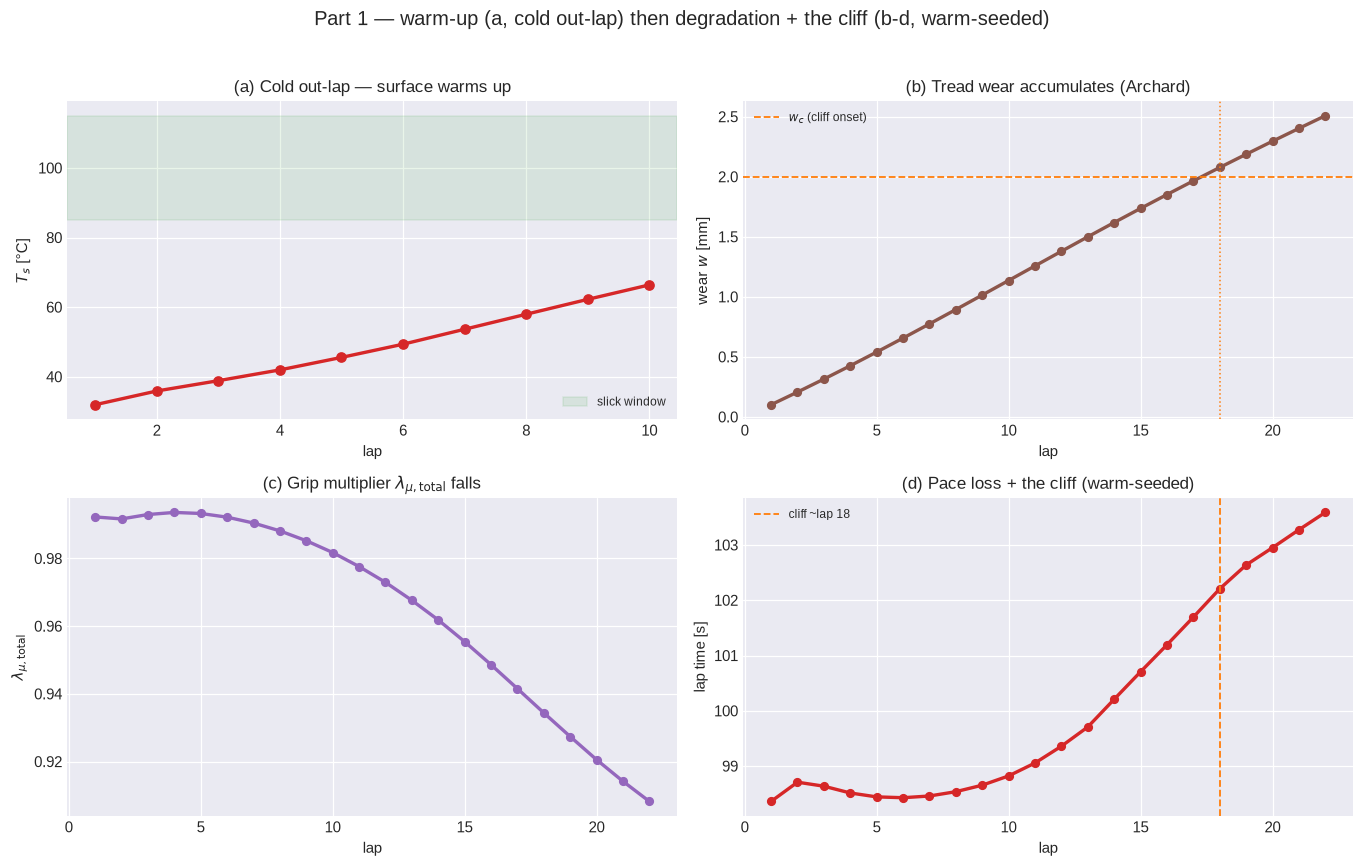

cold out-lap T_s: seed 20 C -> 66 C by lap 10
warm stint wear 0.10 -> 2.51 mm; cliff crossed ~lap 18
warm stint pace loss +5.23 s; grip 0.992 -> 0.908


In [2]:
w_c = 2.0  # cliff onset (calibrated f1_2026 slick .tyr, data/tires/f1_2026_compounds)

# (a) Cold out-lap: watch the surface node warm up out of the 20 C seed toward the window.
cold = solve_stint_dataset(F1, track, n_laps=10, tier="t0", ds_m=16.0, sim=FAST,
                           tire_thermal=True, initial_tire_temp_c=20.0)
surf_cold = cold["tire_surface_c"].values[:, -1]

# (b-d) Warm-seeded stint: the degradation story, uncontaminated by warm-up — wear, grip, and pace.
n1 = 22
warm = solve_stint_dataset(F1, track, n_laps=n1, tier="t0", ds_m=16.0, sim=FAST,
                           tire_thermal=True, initial_tire_temp_c=None)
laps = warm["lap"].values
lt = warm["lap_time_s"].values
wear_end = warm["tire_wear_mm"].values[:, -1]
grip_end = warm["tire_grip"].values[:, -1]
cliff = int(np.argmax(wear_end >= w_c)) + 1 if np.any(wear_end >= w_c) else n1

fig, ax = plt.subplots(2, 2, figsize=(12.5, 8.0))
ax[0,0].plot(cold["lap"].values, surf_cold, "o-", color="tab:red", lw=2.2, ms=6)
ax[0,0].axhspan(85, 115, color="tab:green", alpha=0.10, label="slick window")
ax[0,0].set(title="(a) Cold out-lap — surface warms up", xlabel="lap", ylabel=r"$T_s$ [°C]")
ax[0,0].legend(loc="lower right", fontsize=8)

ax[0,1].plot(laps, wear_end, "o-", color="tab:brown", lw=2.2, ms=5)
ax[0,1].axhline(w_c, color="tab:orange", ls="--", lw=1.2, label="$w_c$ (cliff onset)")
ax[0,1].axvline(cliff, color="tab:orange", ls=":", lw=1.0)
ax[0,1].set(title="(b) Tread wear accumulates (Archard)", xlabel="lap", ylabel="wear $w$ [mm]")
ax[0,1].legend(loc="upper left", fontsize=8)

ax[1,0].plot(laps, grip_end, "o-", color="tab:purple", lw=2.2, ms=5)
ax[1,0].set(title=r"(c) Grip multiplier $\lambda_{\mu,\mathrm{total}}$ falls", xlabel="lap",
            ylabel=r"$\lambda_{\mu,\mathrm{total}}$")

ax[1,1].plot(laps, lt, "o-", color="tab:red", lw=2.2, ms=5)
ax[1,1].axvline(cliff, color="tab:orange", ls="--", lw=1.2, label=f"cliff ~lap {cliff}")
ax[1,1].set(title="(d) Pace loss + the cliff (warm-seeded)", xlabel="lap", ylabel="lap time [s]")
ax[1,1].legend(loc="upper left", fontsize=8)
fig.suptitle("Part 1 — warm-up (a, cold out-lap) then degradation + the cliff (b-d, warm-seeded)")
fig.tight_layout(rect=(0,0,1,0.96)); plt.show()

print(f"cold out-lap T_s: seed {cold['tire_surface_c'].values[0,0]:.0f} C -> {surf_cold[-1]:.0f} C by lap 10")
print(f"warm stint wear {wear_end[0]:.2f} -> {wear_end[-1]:.2f} mm; cliff crossed ~lap {cliff}")
print(f"warm stint pace loss {lt[-1]-lt[0]:+.2f} s; grip {grip_end[0]:.3f} -> {grip_end[-1]:.3f}")

# In-notebook gates.
assert cold['tire_surface_c'].values[0,0] < 25, "cold seed"
assert surf_cold[-1] > surf_cold[0] + 20, "tyres warm up out of the cold seed"
assert np.all(np.diff(wear_end) >= -1e-9), "wear is monotone (Archard)"
assert grip_end[-1] < grip_end[0], "grip degrades over the warm stint"
assert lt[-3:].mean() > lt[:3].mean(), "net pace loss (degradation)"
assert np.any(wear_end >= w_c), "the stint reaches the cliff" 

## Part 2 — QSS ↔ T2 agreement

The fast **T0 (QSS)** tier re-seeds the tyre slow-state march lap-to-lap; the full **T2 (transient)**
tier is one continuous integration across the start/finish line. For strategy work we lean on the
cheap QSS tier, so its **decay rate** must agree with the transient tier. It does — to within the
§13 gate (≤ 0.1 s/lap). The residual is a recorded driver-margin effect (the T2 driver runs at a
stability margin, sliding — hence wearing — a little less); see
[`docs/validation/wear-cliff.md`](../docs/validation/wear-cliff.md).

This is shown on the **validated Limebeer reference** F1 (`limebeer_2014_f1`), where the gate holds;
the F1 2026 car's T2 carries the M4 driver-stability caveat (`docs/validation/limebeer.md`) and its
decay is recorded, not gated.

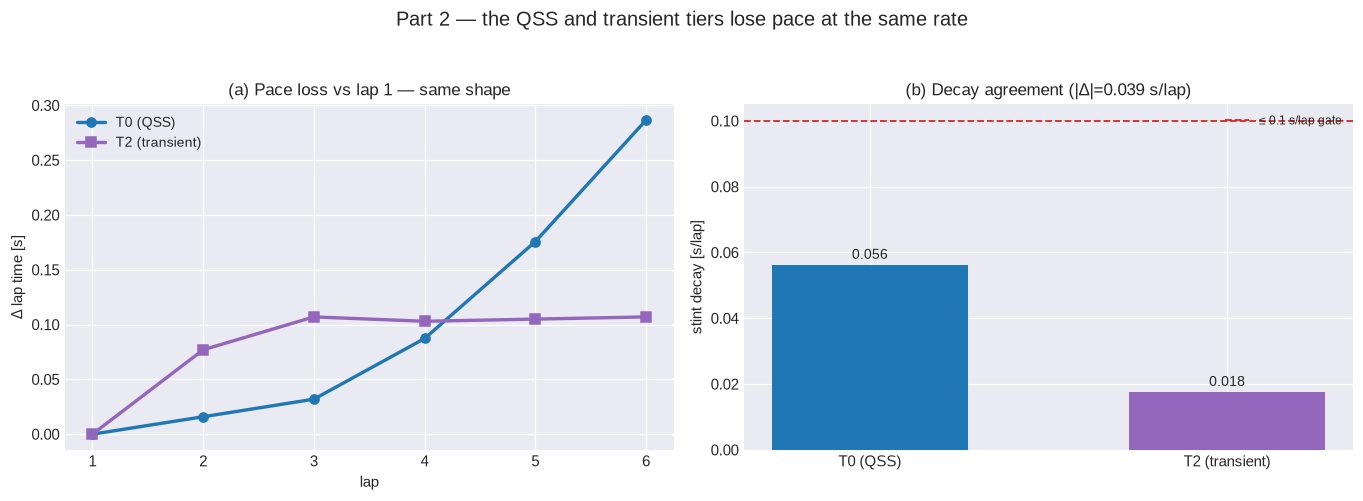

T0 decay 0.056 s/lap; T2 decay 0.018 s/lap; |Δ| 0.039 s/lap


In [3]:
n2 = 6
t0 = solve_stint_dataset(LIMEBEER, track, n_laps=n2, tier="t0", ds_m=12.0, sim=FAST,
                         tire_thermal=True, initial_tire_temp_c=None)
t2 = solve_stint_dataset(LIMEBEER, track, n_laps=n2, tier="t2", ds_m=12.0, sim=FAST,
                         tire_thermal=True, initial_tire_temp_c=None)
assert str(t2.attrs.get("completed")) in ("1", "True"), "T2 stint completed"

def decay(x):
    return float(np.polyfit(np.arange(1, x.size + 1), x, 1)[0])
lt0 = np.asarray(t0["lap_time_s"].values, float)
lt2 = np.asarray(t2["lap_time_s"].values, float)
d0, d2 = decay(lt0), decay(lt2)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax[0].plot(t0["lap"].values, lt0 - lt0[0], "o-", color="tab:blue", lw=2.2, ms=6, label="T0 (QSS)")
ax[0].plot(t2["lap"].values, lt2 - lt2[0], "s-", color="tab:purple", lw=2.2, ms=6, label="T2 (transient)")
ax[0].set(title="(a) Pace loss vs lap 1 — same shape", xlabel="lap", ylabel="Δ lap time [s]")
ax[0].legend(loc="upper left", fontsize=9)
bars = ax[1].bar(["T0 (QSS)", "T2 (transient)"], [d0, d2], color=["tab:blue", "tab:purple"], width=0.55)
ax[1].axhline(0.1, color="tab:red", ls="--", lw=1.2, label="≤ 0.1 s/lap gate")
for b, v in zip(bars, [d0, d2]):
    ax[1].annotate(f"{v:.3f}", (b.get_x()+b.get_width()/2, v), (0,4), textcoords="offset points",
                   ha="center", fontsize=9)
ax[1].set(title=f"(b) Decay agreement (|Δ|={abs(d0-d2):.3f} s/lap)", ylabel="stint decay [s/lap]")
ax[1].legend(loc="upper right", fontsize=8)
fig.suptitle("Part 2 — the QSS and transient tiers lose pace at the same rate")
fig.tight_layout(rect=(0,0,1,0.94)); plt.show()

print(f"T0 decay {d0:.3f} s/lap; T2 decay {d2:.3f} s/lap; |Δ| {abs(d0-d2):.3f} s/lap")
assert d0 > 0 and d2 >= 0, "both tiers degrade"
assert abs(d0 - d2) <= 0.1, "QSS<->T2 stint decay agrees to <= 0.1 s/lap" 

## Part 3 — Multi-compound crossover (the strategy tease)

Three dry slick compounds — **soft / medium / hard** — differing in peak grip, temperature window,
and wear rate (`data/tires/f1_2026_compounds/`). The soft is quickest when fresh but degrades
fastest; the hard is slow to switch on but holds pace. The result is a **lap-time crossover** — and,
integrated, a *cumulative-time* crossover that says which compound wins for a stint of a given
length. That is the undercut/overcut trade-off at the heart of race strategy (dry only — wet is
stage-2).

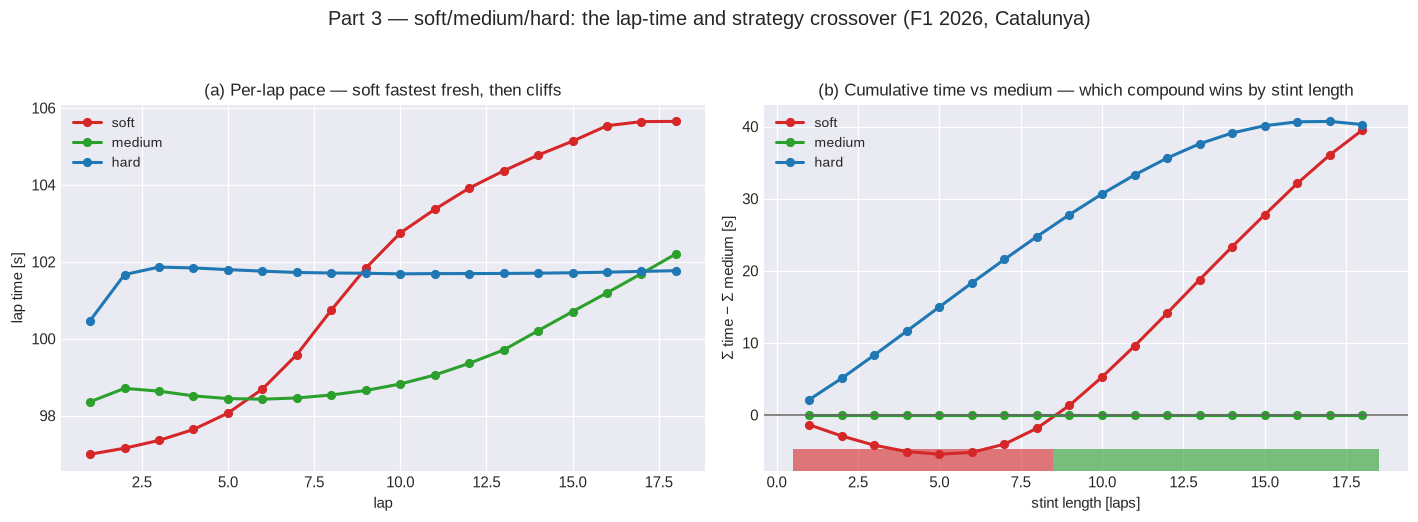

fresh lap: {'soft': np.float64(97.0), 'medium': np.float64(98.36), 'hard': np.float64(100.47)}
optimal compound by stint length: SSSSSSSSMMMMMMMMMM


In [4]:
n3 = 18
runs = {}
for name in ("soft", "medium", "hard"):
    with compound_car(name) as veh:
        ds = solve_stint_dataset(veh, track, n_laps=n3, tier="t0", ds_m=16.0, sim=FAST,
                                 tire_thermal=True, initial_tire_temp_c=None)
    runs[name] = np.asarray(ds["lap_time_s"].values, float)
laps3 = np.arange(1, n3 + 1)
cols = {"soft": C_SOFT, "medium": C_MED, "hard": C_HARD}
cum = {k: np.cumsum(v) for k, v in runs.items()}
# Optimal compound (min cumulative time) for a stint of each length.
best = [min(runs, key=lambda k: cum[k][L-1]) for L in laps3]

fig, ax = plt.subplots(1, 2, figsize=(13.0, 4.8))
for k, v in runs.items():
    ax[0].plot(laps3, v, "o-", color=cols[k], lw=2.0, ms=5, label=k)
ax[0].set(title="(a) Per-lap pace — soft fastest fresh, then cliffs", xlabel="lap", ylabel="lap time [s]")
ax[0].legend(loc="upper left", fontsize=9)
# Cumulative time relative to the medium (the stint-length trade).
for k, v in cum.items():
    ax[1].plot(laps3, v - cum["medium"], "o-", color=cols[k], lw=2.0, ms=5, label=k)
ax[1].axhline(0, color="0.4", lw=1.0)
# Shade the optimal compound band along the bottom.
ymin = ax[1].get_ylim()[0]
for i, L in enumerate(laps3):
    ax[1].axvspan(L-0.5, L+0.5, ymax=0.06, color=cols[best[i]], alpha=0.6, lw=0)
ax[1].set(title="(b) Cumulative time vs medium — which compound wins by stint length",
          xlabel="stint length [laps]", ylabel="Σ time − Σ medium [s]")
ax[1].legend(loc="upper left", fontsize=9)
fig.suptitle("Part 3 — soft/medium/hard: the lap-time and strategy crossover (F1 2026, Catalunya)")
fig.tight_layout(rect=(0,0,1,0.94)); plt.show()

fresh = {k: v[0] for k, v in runs.items()}
print("fresh lap:", {k: round(v,2) for k,v in fresh.items()})
print("optimal compound by stint length:", "".join({"soft":"S","medium":"M","hard":"H"}[b] for b in best))
assert fresh["soft"] < fresh["medium"] < fresh["hard"], "soft grips most when fresh"
assert runs["soft"][-1] > runs["hard"][-1], "soft has cliffed below the hard by stint end"
assert best[0] == "soft" and best[-1] != "soft", "short stint favours soft; long stint does not" 

## Takeaways

- A **stint** is now first-class: tyres **warm up**, **wear**, and fall off a **cliff**, and the slow
  state carries lap-to-lap in both tiers.
- The cheap **QSS** tier and the full **transient** tier agree on the **degradation rate** (≤ 0.1
  s/lap), so strategy sweeps can run at QSS speed.
- **Compounds** trade grip for durability, producing the lap-time and cumulative-time **crossover**
  that underpins pit strategy — the bridge to the stage-2 Monte-Carlo strategy layer.

All tyre parameters are inverse-calibrated by `outlap.wearcal`; the physics is in
[`docs/theory/tire-thermal.md`](../docs/theory/tire-thermal.md) +
[`tire-wear.md`](../docs/theory/tire-wear.md), validated in
[`docs/validation/wear-cliff.md`](../docs/validation/wear-cliff.md).